# bolojax quickstart

Run a sensitivity calculation, explore the results, modify parameters,
and save/load datasets.


## 1. Load a config and compute sensitivity


In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import yaml

import bolojax

repo = Path("..").resolve()
fixtures = repo / "tests" / "fixtures"
config_dir = str(repo / "config")

In [2]:
# Load config
with (fixtures / "comprehensive.yaml").open() as f:
    cfg = yaml.safe_load(f)
cfg["sim_config"]["config_dir"] = config_dir

config = bolojax.ExperimentConfig(**cfg)

# Setup builds the JAX compute objects for a specific camera/channel
experiment = config.setup(camera="cam_1", channel="chan_1")

# Compute returns a SensitivityResult pytree
result = experiment.compute()

# Quick summary
print(f"NET:        {float(np.squeeze(result.NET)) * 1e6:.1f} uK rt(s)")
print(f"NET_corr:   {float(np.squeeze(result.NET_corr)) * 1e6:.1f} uK rt(s)")
print(f"corr_fact:  {float(np.squeeze(result.corr_fact)):.4f}")
print(f"opt_power:  {float(np.squeeze(result.opt_power)) * 1e12:.2f} pW")
print(f"efficiency: {float(np.squeeze(result.effic)):.4f}")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


NET:        597.2 uK rt(s)
NET_corr:   621.4 uK rt(s)
corr_fact:  1.0405
opt_power:  13.69 pW
efficiency: 0.6766


## 2. Convert to xarray and explore

`to_dataset()` produces a labeled xarray Dataset with units metadata.


In [3]:
element_names = list(experiment.instrument.elements.keys())
ds = result.to_dataset(element_names)
ds

<xarray.Dataset> Size: 2kB
Dimensions:              (dim_0: 1, dim_1: 1, element: 16)
Coordinates:
  * element              (element) <U14 896B 'cmb' 'dust' ... 'detector'
Dimensions without coordinates: dim_0, dim_1
Data variables: (12/28)
    effic                (dim_0, dim_1) float64 8B 0.6766
    opt_power            (dim_0, dim_1) float64 8B 13.69
    P_sat                (dim_0, dim_1) float64 8B 41.06
    G                    (dim_0, dim_1) float64 8B 1.151e+03
    Flink                (dim_0, dim_1) float64 8B 0.5081
    tel_power            (dim_0, dim_1) float64 8B 3.002
    ...                   ...
    NET_corr_RJ          (dim_0, dim_1) float64 8B 494.5
    NET_arr              (dim_0, dim_1) float64 8B 13.63
    NET_arr_RJ           (dim_0, dim_1) float64 8B 10.85
    corr_fact            (dim_0, dim_1) float64 8B 1.041
    map_depth            (dim_0, dim_1) float64 8B 1.607e+04
    map_depth_RJ         (dim_0, dim_1) float64 8B 1.279e+04

In [4]:
# Per-element optical power reaching the detector
ds.elem_power_to_det

<xarray.DataArray 'elem_power_to_det' (element: 16, dim_0: 1, dim_1: 1)> Size: 128B
array([[[2.34406482e-01]],

       [[1.36820705e-07]],

       [[7.21948765e-07]],

       [[1.00625700e+01]],

       [[3.87493110e-01]],

       [[1.91685334e-01]],

       [[6.19352971e-01]],

       [[1.85478818e+00]],

       [[5.39620860e-02]],

       [[4.03578384e-02]],

       [[2.15224844e-01]],

       [[1.98775537e-02]],

       [[5.00200324e-04]],

       [[6.28559787e-03]],

       [[6.04666791e-09]],

       [[0.00000000e+00]]])
Coordinates:
  * element  (element) <U14 896B 'cmb' 'dust' ... 'lowpass' 'detector'
Dimensions without coordinates: dim_0, dim_1
Attributes:
    units:    picowatt

## 3. Plot the optical power budget


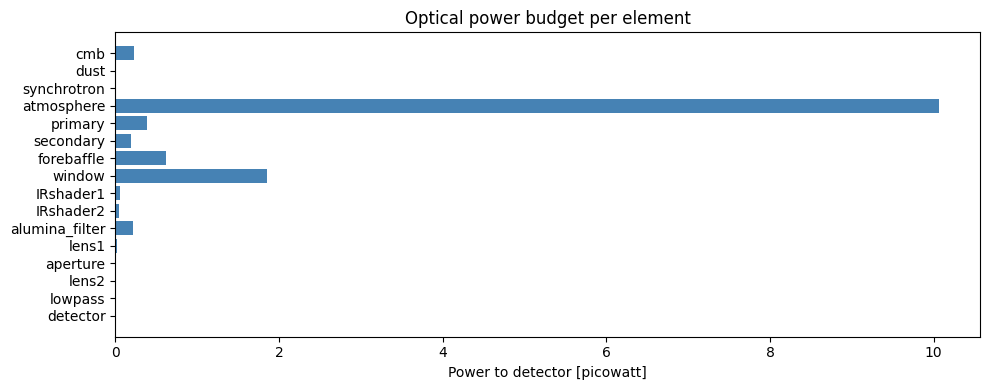

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
power = np.asarray(ds.elem_power_to_det.values).squeeze()
names = list(ds.element.values)
ax.barh(range(len(names)), power, color="steelblue")
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names)
ax.set_xlabel(f"Power to detector [{ds.elem_power_to_det.attrs.get('units', 'pW')}]")
ax.set_title("Optical power budget per element")
ax.invert_yaxis()
plt.tight_layout()

## 4. Modify a parameter and recompute

bolojax uses zodiax, so parameters can be updated with `.set()` on the
experiment pytree. The entire chain is JAX-traceable.


In [6]:
# Double the window absorption
exp2 = experiment.set("instrument.elements.window.absorption", jnp.array(0.01))
result2 = exp2.compute()

net_orig = float(np.squeeze(result.NET)) * 1e6
net_new = float(np.squeeze(result2.NET)) * 1e6
print(f"Original NET: {net_orig:.1f} uK rt(s)")
print(f"Window 2x abs: {net_new:.1f} uK rt(s)")
print(f"Degradation:  {(net_new / net_orig - 1) * 100:.1f}%")

Original NET: 597.2 uK rt(s)
Window 2x abs: 613.3 uK rt(s)
Degradation:  2.7%


## 5. Differentiate through the computation

Since the entire computation is JAX-traceable, we can take derivatives
of any output with respect to any input parameter.


In [7]:
# dNET/d(loss_tangent) for lens1
def net_from_lt(lt):
    exp = experiment.set("instrument.elements.lens1.loss_tangent", lt)
    return exp.compute().NET.squeeze()


lt0 = experiment.instrument.elements["lens1"].loss_tangent
grad = jax.grad(net_from_lt)(lt0)
print(f"loss_tangent = {float(lt0):.2e}")
print(f"dNET/d(loss_tangent) = {float(grad) * 1e6:.2f} uK rt(s) per unit lt")

loss_tangent = 2.60e-04
dNET/d(loss_tangent) = 8265.10 uK rt(s) per unit lt


## 6. Save and load results

xarray datasets save to NetCDF (or Zarr) with full dimension labels and
unit metadata preserved.


In [ ]:
out = Path("/tmp/bolojax_quickstart.nc")

ds.to_netcdf(out)
print(f"Saved to {out} ({out.stat().st_size / 1024:.1f} KB)")

ds_loaded = xr.open_dataset(out)
ds_loaded

Saved to /tmp/bolojax_quickstart.nc (4.2 KB)


<xarray.Dataset> Size: 832B
Dimensions:              (element: 16, dim_0: 1, dim_1: 1)
Coordinates:
  * element              (element) object 128B 'cmb' 'dust' ... 'detector'
Dimensions without coordinates: dim_0, dim_1
Data variables: (12/28)
    elem_effic           (element, dim_0, dim_1) float64 128B ...
    elem_cumul_effic     (element, dim_0, dim_1) float64 128B ...
    elem_power_from_sky  (element, dim_0, dim_1) float64 128B ...
    elem_power_to_det    (element, dim_0, dim_1) float64 128B ...
    effic                (dim_0, dim_1) float64 8B ...
    opt_power            (dim_0, dim_1) float64 8B ...
    ...                   ...
    NET_corr_RJ          (dim_0, dim_1) float64 8B ...
    NET_arr              (dim_0, dim_1) float64 8B ...
    NET_arr_RJ           (dim_0, dim_1) float64 8B ...
    corr_fact            (dim_0, dim_1) float64 8B ...
    map_depth            (dim_0, dim_1) float64 8B ...
    map_depth_RJ         (dim_0, dim_1) float64 8B ...

In [9]:
# Unit metadata survives the round-trip
print("NET units:", ds_loaded.NET.attrs.get("units", "none"))
print(
    "NET value:",
    float(ds_loaded.NET.values.squeeze()),
    ds_loaded.NET.attrs.get("units", ""),
)

# Access per-element data by name
print(
    "\nPower from lens1:",
    float(ds_loaded.elem_power_to_det.sel(element="lens1").values.squeeze()),
    ds_loaded.elem_power_to_det.attrs.get("units", ""),
)

# Clean up
out.unlink()

NET units: microkelvin * second ** 0.5
NET value: 597.2168431793875 microkelvin * second ** 0.5

Power from lens1: 0.019877553696770252 picowatt
